This workbook implements a form of generalised profiling: Newton's law of cooling with synthetic data. 

Matthew J Simpson - QUT

Ruth E Baker - Oxford

December 2025

In [1]:
using Plots, DifferentialEquations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Statistics
using SparseArrays, StatsAPI, LinearAlgebra
gr(); #Load packages 

In [2]:
Tend = 100;
t=LinRange(0,Tend,11);    #Discretised time variable, coarse discretisation for data J = 11
tf=LinRange(0,Tend,1001); #Discretised time variable, fine discretisation for ODE enforcing K = 1001
int = 20;
t_exact(time) = 20 + 160*exp(-time/20)
dt_exact(time) = -8*exp(-time/20)
data = [172.52963098608188
 131.2870617461668
  73.56389927679663
  62.939375577813976
  38.8392461185434
  38.665760026684474
  21.212445277871357
  37.2698938900581
  27.017801397794816
  24.652496127526355
  28.03908867548565];

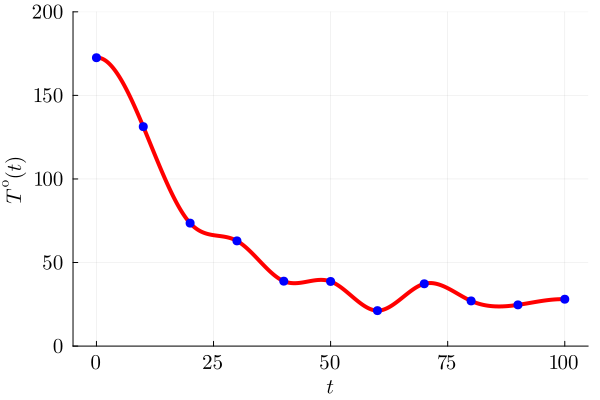

In [3]:
S_interp = interpolate(t, data, BSplineOrder(4)) #Create spline to overfit the data
B = basis(S_interp);                             #Basis functions
Coeff = coefficients(S_interp)                   #Spline coefficients

Csp = collocation_matrix(B, t, Derivative(0), SparseMatrixCSC{Float64, Int});    #Collocation matrix for the function on the coarse grid
Cspf = collocation_matrix(B, tf, Derivative(0), SparseMatrixCSC{Float64, Int});  #Collocation matrix for the function on the fine grid
C1spf = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int}); #Collocation matrix for the first derivative on the fine grid

Temp  = Csp*Coeff;   #Evaluate spline for the function on the coarse grid
Tempf  = Cspf*Coeff  #Evaluate spline for the function on the fine grid
dTf = C1spf*Coeff    #Evaluate spline for the first derivative on the fine grid


p1 = plot(tf,Tempf,lw=4,lc=:red,label=false) #Plot results
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p1=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
#savefig("f3a.svg")

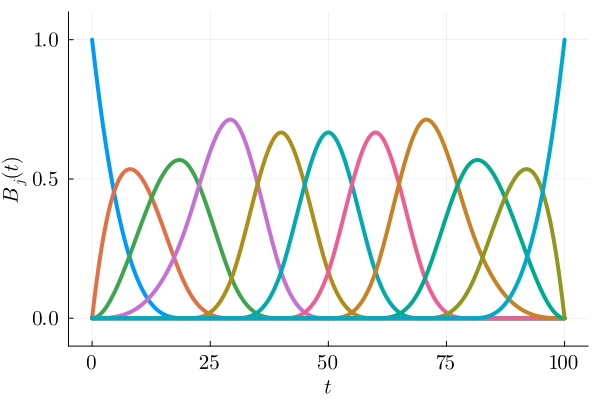

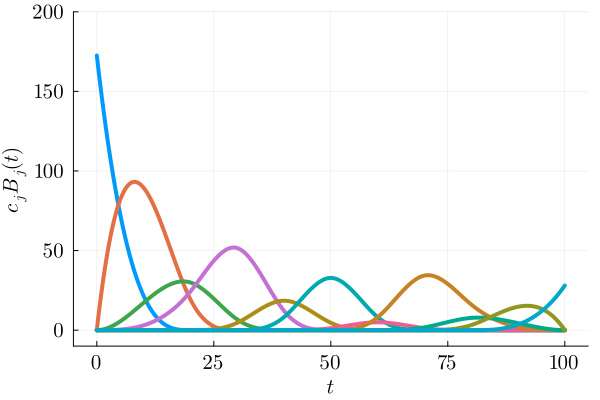

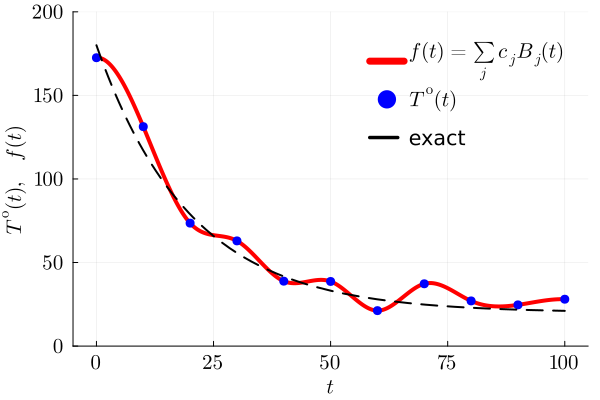

In [4]:
# Plot all basis functions
pB = plot(; xlabel=L"t", ylabel=L"B_j(t)",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pB, tf, Cspf[:, j],lw=4,label=false)
end
pB=plot!(xlabel=L"t",ylabel=L"B_j(t)",xlims=(t[1]-5,t[end]+5), ylims=(-0.1,1.1),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0.0,0.5,1.0],[L"0.0", L"0.5", L"1.0"]),label=false)
pB=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pB)
#savefig("f1b.svg")

pBscaled = plot(; xlabel=L"t", ylabel=L"c_j B_j(t)",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pBscaled, tf, Coeff[j]*Cspf[:, j],lw=4,label=false)
end
pBscaled=plot!(xlabel=L"t",ylabel=L"c_j B_j(t)",xlims=(t[1]-5,t[end]+5),  ylims=(-10,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
pBscaled=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBscaled)
savefig("f1c.svg")

p1 = plot(tf,Tempf,lw=4,lc=:red,label=L"f(t) = \sum_j \, c_j B_j(t)")
p1=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=L"T^{\textrm{o}}(t)")
p1 = plot!(t_exact,0,Tend,lc=:black, lw=2, ls=:dash,label="exact")
p1=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t), \quad f(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]))
p1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, legend = :topright, background_color_legend = :transparent,
    foreground_color_legend = :transparent, legendfontsize = 14)
display(p1)
#savefig("f1a.svg")

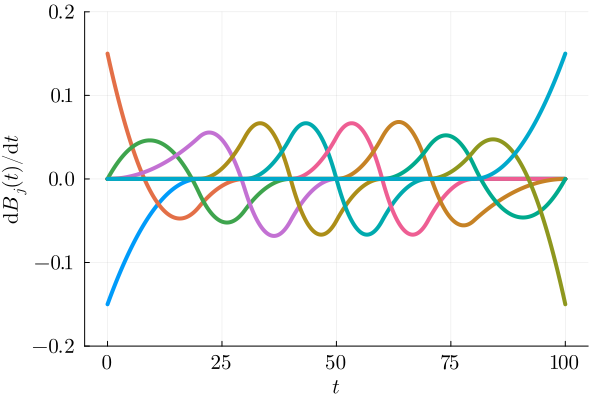

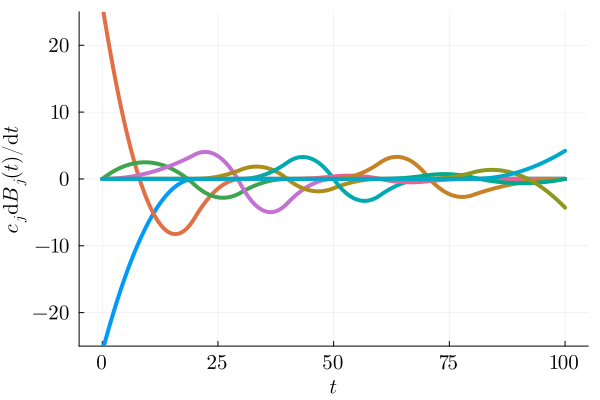

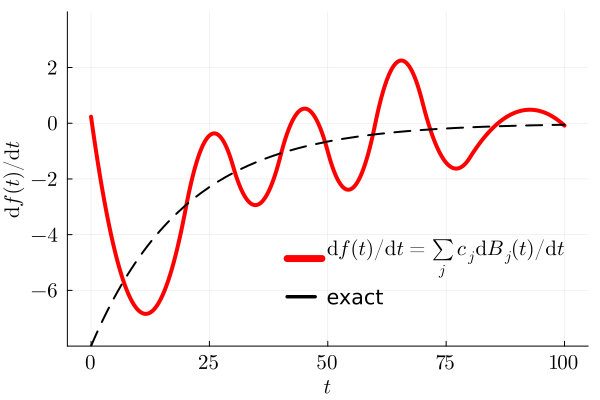

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f2c.svg"

In [5]:
Csp_deriv = collocation_matrix(B, tf, Derivative(1), SparseMatrixCSC{Float64, Int}) 

# Plot basis function derivatives
pB = plot(; xlabel=L"t", ylabel=L"\textrm{d}B_j(t)/\textrm{d}t",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pB, tf, Csp_deriv[:, j],lw=4,label=false)
end
pBd=plot!(xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
pBd=plot!(ylims=(-0.20,0.20),yticks = ([-0.20,-0.10,0.0,0.10,0.20],[L"-0.2", L"-0.1", L"0.0", L"0.1", L"0.2"]),label=false)
pBd=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBd)
#savefig("f2a.svg")

pBscaledd = plot(; xlabel=L"t", ylabel=L"c_j \textrm{d}B_j(t)/\textrm{d}t",
          xlims=(tf[1]-5, tf[end]+5))

for j in 1:length(t)
    plot!(pBscaledd, tf, Coeff[j]*Csp_deriv[:, j],lw=4,label=false)
end
pBscaledd=plot!(xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]),label=false)
pBdscaled=plot!(ylims=(-25,25),yticks = ([-20,-10,0,10,20],[L"-20", L"-10", L"0", L"10", L"20"]),label=false)
pBscaledd=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(pBscaledd)
#savefig("f2b.svg")

p1d = plot(tf,dTf,lw=4,lc=:red,label=L"\textrm{d}f(t)/\textrm{d}t = \sum_j \, c_j \textrm{d}B_j(t)/\textrm{d}t")
p1d=plot!(xlabel=L"t",ylabel=L"\textrm{d}f(t)/\textrm{d}t",color=:red,xlims=(t[1]-5,t[end]+5),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]))
p1d=plot!(ylims=(-8,4),yticks = ([-6,-4,-2,0,2],[L"-6", L"-4", L"-2", L"0", L"2"]),label=false)
p1d=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14, legend = :bottomright, background_color_legend = :transparent,
    foreground_color_legend = :transparent, legendfontsize = 14)
p1d = plot!(dt_exact,0,Tend,lc=:black, lw=2, ls=:dash,label="exact")
display(p1d)

savefig("f2c.svg")

In [6]:
function loglhood(data,Temp,Tempf,dTf,t,tf,w,a) #Function to evaluate the loglikelihood of the data stored in the vector data. 
ℓ =0; ℓd =0; ℓm =0;    
dist=Normal(0,a[3]) 
ℓd+=loglikelihood(dist,data-Temp)  
ℓm = sum((dTf.+ a[2] .* (Tempf.- a[1])).^2) / length(tf) 
ℓ = w[1]*ℓd - w[2]*ℓm;
return ℓ
end;

In [7]:
function Optimise(fun,θ₀,lb,ub) #Optimize finds the values of parameters \theta that maximise the objective function fun with lower bounds lb, and upper bounds ub
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_NELDERMEAD,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = optimize(opt,θ₀)
    return res[[2,1]]
end

Optimise (generic function with 1 method)

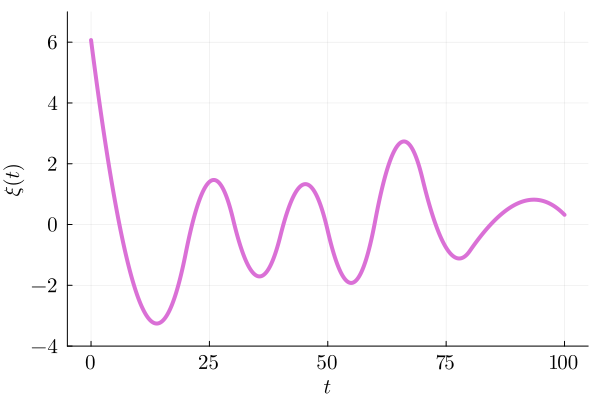

In [8]:
Tamin=0; Tamax=100; kmin=0; kmax=1; σmin = 0.1; σmax=50;  #Lower/upper bounds
θG=[20, 0.05, 2.0] #Iniitial estimate of the parameter values
lb=[Tamin,kmin,σmin]
ub=[Tamax,kmax,σmax]
a = zeros(3)
w = [1,1];
funopt(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ1,fopt)=Optimise(funopt,θG,lb,ub) #Call to NLopt to provide the first estimate of the parameters 
a1 = plot(tf, dTf.+ θ1[2].*(Tempf.-θ1[1]),lw=4,color=:orchid,msc=:orchid,legend=false) #Plot xi
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
#savefig("f3aa.svg")

Iteration 2

In [9]:
ℓd=0; ℓm =0
ℓd+=loglikelihood(Normal(0,θ1[3]) ,data-Temp)  
ℓm = sum((dTf .+ a[2] .* (Tempf .- a[1])).^2) / length(tf) 
w = [1.0,abs(1/ℓm)];
funopt1(a) = loglhood(data,Temp,Tempf,dTf, t, tf,w, a) #Here setting the weight to one
(θ2,fopt)=Optimise(funopt1,θG,lb,ub) #Call to NLopt to estimate the updated paramters 

([17.22918829582023, 0.03757285838054631, 0.1], 14.84641224521119)

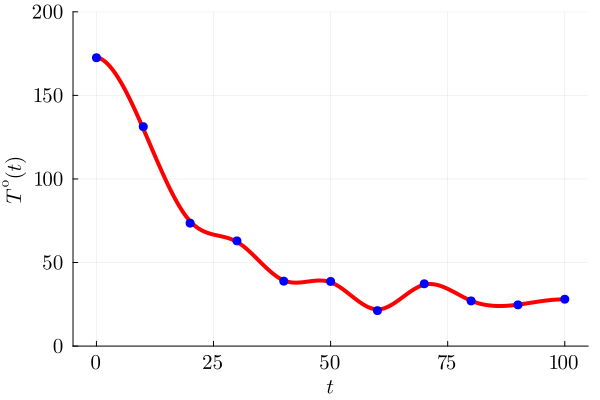

In [10]:
d1=zeros(length(tf)); d0=zeros(length(t));
d0=data;
d1 = [-θ1[2] * (Tempf[i] - θ1[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [11]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ1[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ1[2] .* (Tempf .- θ2[1])).^2) / length(tf) 

println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 214.4002479351311
Model distance 2.180828849633987


Iteration 3

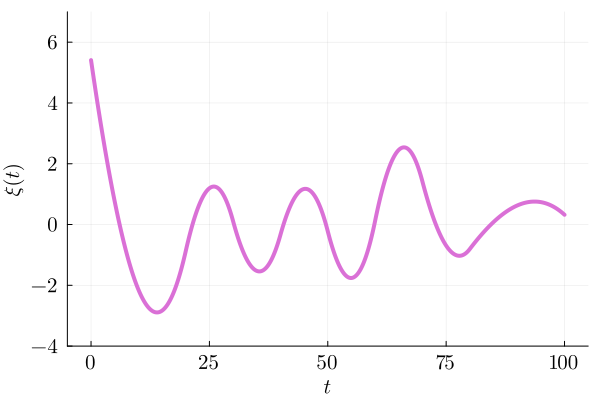

In [12]:
funopt3(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ3,fopt)=Optimise(funopt3,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ3[2].*(Tempf.-θ3[1]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

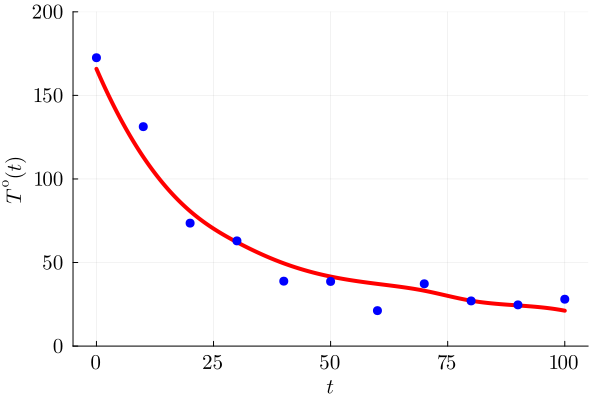

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f3c.svg"

In [13]:
d1 = [-θ3[2] * (Tempf[i] - θ3[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)
savefig("f3c.svg")

In [14]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ3[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ3[2] .* (Tempf .- θ3[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 1042.8130023511703
Model distance 0.09451686173577634


Iteration 4

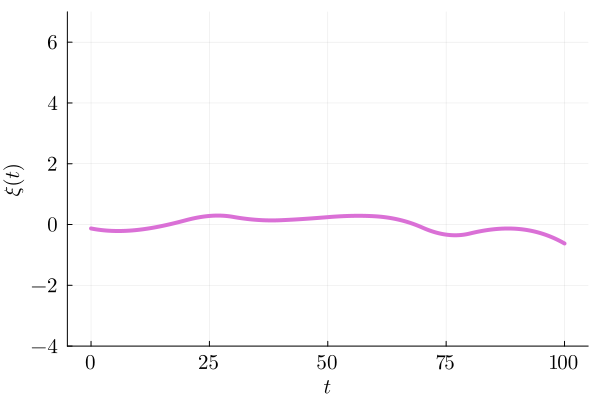

In [15]:
funopt4(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ4,fopt)=Optimise(funopt4,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ4[2].*(Tempf.-θ4[1]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
#savefig("f3cc.svg")

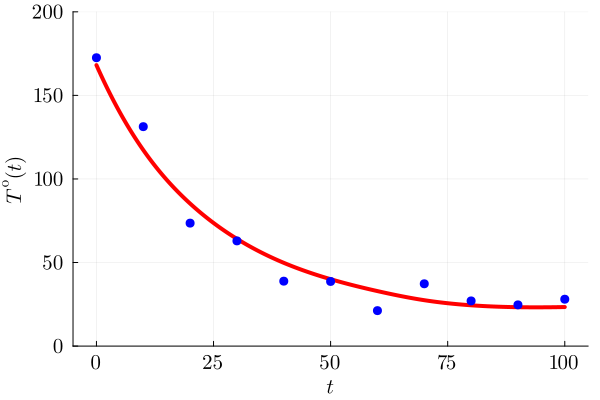

"C:\\Users\\simpsom3\\Dropbox\\Generalised Profiling\\Notebooks\\f3d.svg"

In [16]:
d1 = [-θ4[2] * (Tempf[i] - θ4[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)
savefig("f3d.svg")

In [17]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ4[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ4[2] .* (Tempf .- θ4[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.817574493117384
Model distance 0.020951936856043345


Iteration 5

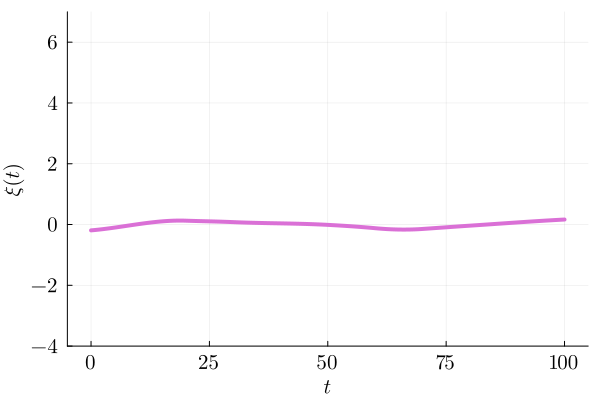

In [18]:
funopt5(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ5,fopt)=Optimise(funopt5,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ5[2].*(Tempf.-θ5[1]), lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
#savefig("f3dd.svg")

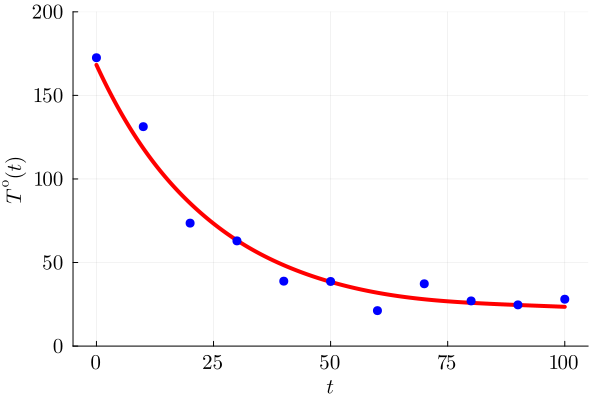

In [19]:
d1 = [-θ5[2] * (Tempf[i] - θ5[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [20]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ5[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ5[2] .* (Tempf .- θ5[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.02579798054756
Model distance 0.002052886999311803


Iteration 6

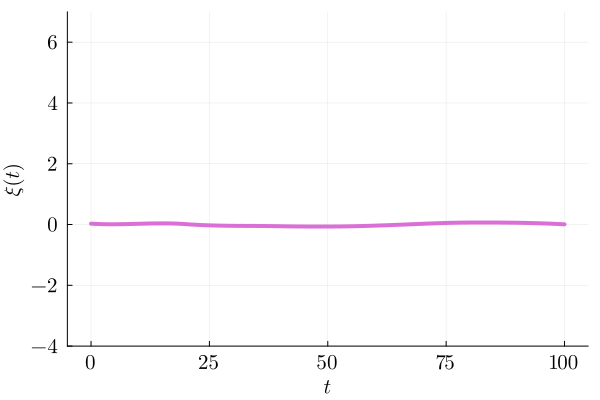

In [21]:
funopt6(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ6,fopt)=Optimise(funopt6,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ6[2].*(Tempf.-θ6[1]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

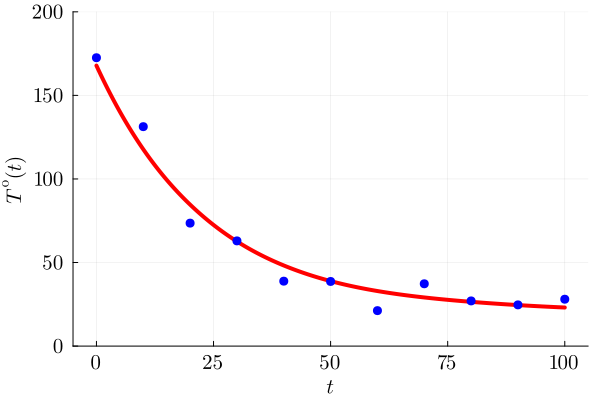

In [22]:
d1 = [-θ6[2] * (Tempf[i] - θ6[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [23]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ6[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ6[2] .* (Tempf .- θ6[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.00764180644498
Model distance 0.0007986845185336262


Iteration 7

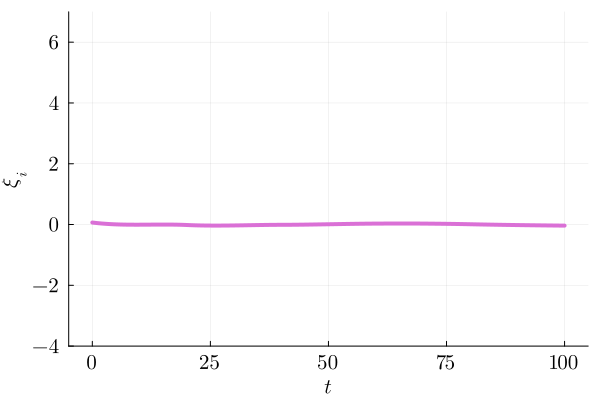

In [24]:
funopt7(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ7,fopt)=Optimise(funopt7,θG,lb,ub) #Call to NLopt 
a1 = plot(tf, dTf.+ θ7[2].*(Tempf.-θ7[1]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi_i",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

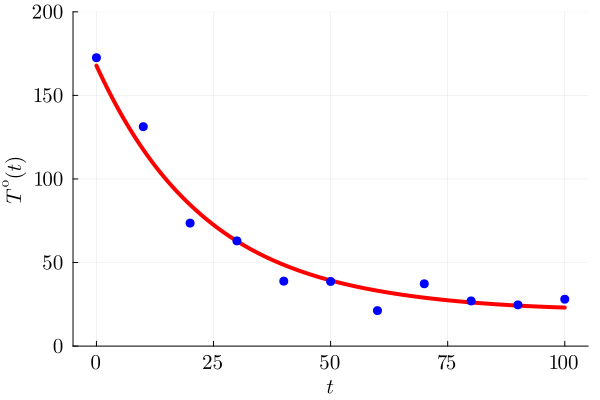

In [25]:
d1 = [-θ7[2] * (Tempf[i] - θ7[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [26]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ7[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ7[2] .* (Tempf .- θ7[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.16924947904059
Model distance 0.000142741572711111


Iteration 8

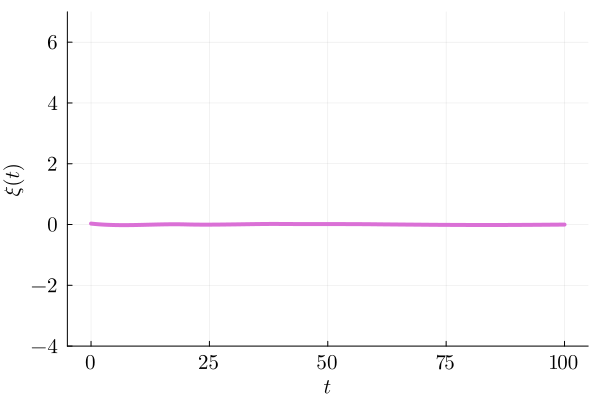

In [27]:
funopt8(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ8,fopt)=Optimise(funopt8,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ8[2].*(Tempf.-θ8[1]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

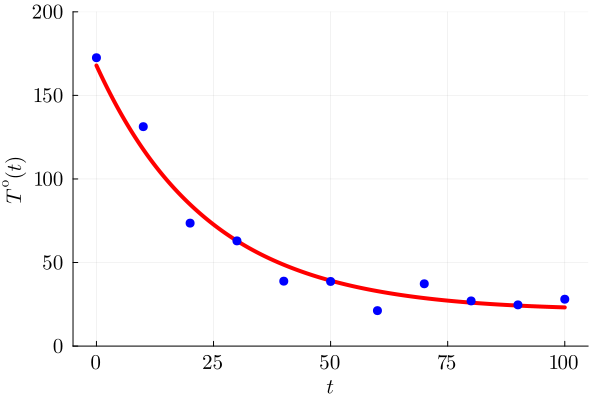

In [28]:
d1 = [-θ8[2] * (Tempf[i] - θ8[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [29]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ8[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ8[2] .* (Tempf .- θ8[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.15358331449843
Model distance 7.385191175114425e-5


Iteration 9

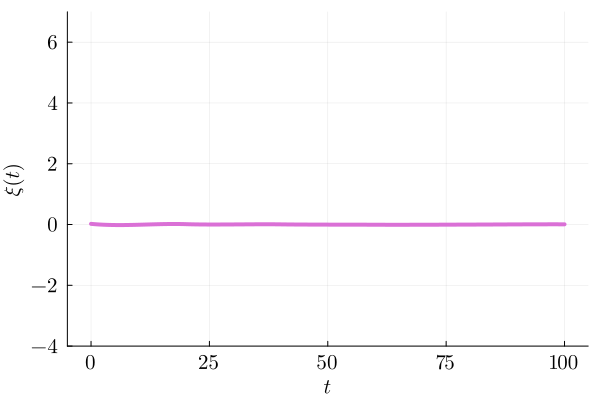

In [30]:
funopt9(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ9,fopt)=Optimise(funopt9,θG,lb,ub) #Call to NLopt 
a1 = plot(tf,dTf.+ θ9[2].*(Tempf.-θ9[1]),lw=4,color=:orchid,msc=:orchid,legend=false)
a1=plot!(xlabel=L"t",ylabel=L"\xi(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(-4,7),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([-4,-2,0,2,4,6],[L"-4", L"-2", L"0", L"2",L"4",L"6"]),label=false)
a1=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)

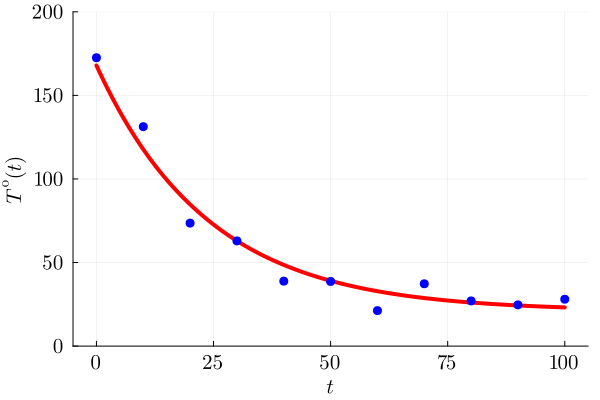

In [31]:
d1 = [-θ9[2] * (Tempf[i] - θ9[1]) for i in eachindex(tf)];

Coeff = vcat(w[1]*Csp,w[2]*C1spf) \ vcat(w[1]*d0,w[2]*d1)

p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:blue,ms=5,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
display(p4)

In [32]:
Temp = Csp*Coeff; Tempf = Cspf*Coeff; dTf = C1spf*Coeff;

ℓd=0
ℓd+=-1*loglikelihood(Normal(0,θ9[3]) ,data-Temp)  
ℓm =0;
ℓm = sum((dTf .+ θ9[2] .* (Tempf .- θ9[1])).^2) / length(tf) 


println("Data distance ",ℓd)
println("Model distance ",ℓm)
w[1] = abs(1/ℓd); w[2] = abs(1/ℓm);

Data distance 38.11498906953389
Model distance 3.60534550210485e-5


Iteration 10

In [33]:
funopt10(a) = loglhood(data,Temp,Tempf,dTf, t, tf, w, a) #Here setting the weight to one
(θ10,fopt)=Optimise(funopt10,θG,lb,ub) #Call to NLopt 

([20.832878634634756, 0.04169439587744195, 7.737263671184168], -1.9984340593886758)

In [34]:
T0 = Tempf[1];
fe(t) = (T0-θ9[1])*exp(-θ9[2]*t)+θ9[1]

fe (generic function with 1 method)

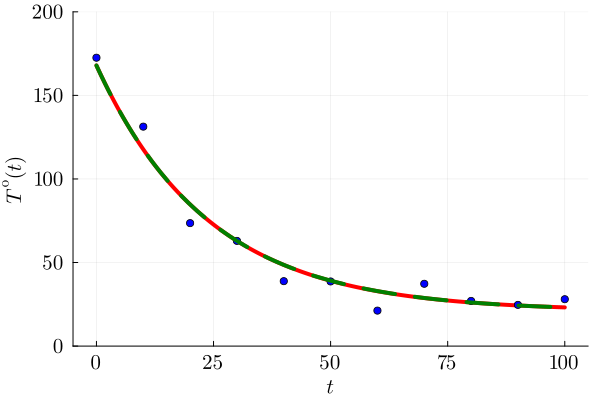

In [35]:
p4 = plot(tf,Cspf*Coeff; lw=4,lc=:red,label=false)
p4=scatter!(t,data,mc=:blue,msc=:match,label=false)
p4=plot!(xlabel=L"t",ylabel=L"T^{\textrm{o}}(t)",color=:red,xlims=(t[1]-5,t[end]+5), ylims=(0,200),xticks = ([0,25,50, 75, 100],[L"0", L"25", L"50", L"75", L"100"]), yticks = ([0,50,100,150,200],[L"0", L"50", L"100", L"150",L"200"]),label=false)
p4=plot!(xguidefontsize=14, yguidefontsize=14,xtickfontsize=14, ytickfontsize=14)
p4=plot!(fe,0,Tend,lw=4,lc=:green,ls=:dash,legend=false)
display(p4)

In [36]:
θ1

3-element Vector{Float64}:
 17.22918781179962
  0.03757285823311262
  0.1

In [37]:
θ2

3-element Vector{Float64}:
 17.22918829582023
  0.03757285838054631
  0.1

In [38]:
θ3

3-element Vector{Float64}:
 17.971288258087302
  0.03854894100234004
  0.6461358788288251

In [39]:
θ4

3-element Vector{Float64}:
 23.1100734015073
  0.044338964983129225
  8.874388051865253

In [40]:
θ5

3-element Vector{Float64}:
 20.590035048530307
  0.04146478421799301
  8.198728913549035

In [41]:
θ6

3-element Vector{Float64}:
 20.491231296353696
  0.04132428289439138
  7.638233162044951

In [42]:
θ7

3-element Vector{Float64}:
 20.92426359207521
  0.04178988930269434
  7.662143865846405

In [43]:
θ8

3-element Vector{Float64}:
 20.937625155433796
  0.0418099757641262
  7.773972297445912

In [44]:
θ9

3-element Vector{Float64}:
 20.837345654540634
  0.04170069461139966
  7.764542638740484

In [45]:
θ10

3-element Vector{Float64}:
 20.832878634634756
  0.04169439587744195
  7.737263671184168